In [1]:
"""
Import the packages needed to simulation of detections and modelling orbital distributions.
"""
%load_ext autoreload
%autoreload 2
import ossssim
from ossssim import models
from ossssim import OSSSSim, DetectFile, ModelFile, ModelOutputFile 
from astropy import units
import numpy
import os


In [2]:
# setup some paths to characterization files and where to store your model outputs.
CHARACTERIZATION_DIR="Surveys"
MODEL_OUTPUT_DIR=os.getenv('HOME')

In [3]:
# I load this Distributions object here so I can select on the Context Senstive Help 
# On the object (click on Distributions) and see what funcitons are defined. 
from ossssim.distributions import Distributions

In [4]:
# We create new populations by defining a new class of Parametric or Implanted class defined in models. 
# A Parametric based orbit model gets a 'cold-classical' H-distribution by default while an Implanted based model gets a 
# H-distribution that is more consistent with the hot-classicals

# NOTE The distributions of orbital elemetns are set by defining the functions with names that match the pattern:
# {element}_distribution  (e.g. a_distribution, e_distribution, M_distribution where the value of element is one of
# [a, e, inc, node, peri, M, H, peri, phi]

# NOTE: When defining a distribution we call the distributions attached to the model (e.g. self.distributions.FUNCTION_NAME )
# this is to ensure that all our distributions are seeded with a common random number and we can thuse re-produce a model if 
# we know the seed value.

class Hot(models.Implanted):
    """
    Class used to create hot classical belt objects.  These model classes generate the orbit/H distributions and provide methods to 
    access the generated srouces.

    To build an orbit distribution one defines:

    a_distribution
    e_distribution or q_distribution
    inc_distribution

    By default 'Implanted' class objects have randomized {M|Omega|omega}_distribution functions.
    
    """
    def __init__(self, q_min=36*units.au, q_max=40*units.au, q_centre=38*units.au,
                 q_width=1*units.au, a_max=100*units.au, a_beta=-5/2, model_band='r', 
                 size=100000, **kwargs):
        """Build a Hot model orbital element distribution based on the peri-centre distribution 
        and declining 'a' distributions as a^beta power
                    
        """
        super().__init__(size=size, H_max=12.5, model_band=model_band, **kwargs)
        # We will define a q_distribution method and here we define the parameters needed for that distribution.
        self.q_min = q_min
        self.q_max = q_max
        self.q_centre = q_centre
        self.q_width = q_width
        # define the parameters needed for our 'a_distribution' defined below.
        self.a_max = a_max
        self.a_beta = a_beta

    @property
    def q_distribution(self):
        """
        This function defines the distribution of 'q' values that model objects will have.  Here
        we are using the 'distributions' instance of 'Implanted' to create a normal distribution of 
        q values.   The 'distributions' instance of the Distributions class keeps track of the random
        number generator and the size of sample each call should provide.  The seed and size are 
        set when this 'Hot' class is frist instantiated. 
        
        A Normal or Gaussian distribution where we clip values above max and below min to remove
        the long tails of the Normal disrtibution.
        """
        return self.distributions.truncated_normal(mu=self.q_centre.to('au').value, 
                                                   maximum=self.q_max.to('au').value, 
                                                   minimum=self.q_min.to('au').value, 
                                                   sigma=self.q_width.to('au').value) * units.au

    @property
    def q(self):
        if self._q is None:
            self._q = self.q_distribution
        return self._q

    @property
    def a_distribution(self):
        """
        Limited to be larger than 'q' but and declining in density with a to the power -5/2
        """

        # Following is a standard pattern for creating your own distribution of a value.
        # This approach works for distributions that are monotomic and easy to interpolate over.

        # First define a vector that samples the range of values we should return.  
        # Model is to sample 'a' values that extend from q_min to some 'a_max'.  
        # This choice of limits on 'a' is our model, other choices could be made.
        fp = numpy.linspace(self.q_min.to('au').value, 
                            self.a_max.to('au').value, 
                            num=1000)

        # now compute the value of the distribution function between those ranges.
        xp = (fp/self.q_min.to('au').value)**self.a_beta
        xp = xp.cumsum() / xp.sum()  # Normalizes the cdf
        
        # we don't what a fully uniform distribution of 'xp' (likelihood of a given a value) 
        # as we have the additional constraint that a must be > q so we need to eliminate the 'xp' 
        # values that would return fp < q (i.e. the distribution is undefined for cases where a<q).
        xp_min = numpy.interp(self.q.to('au').value,  # these are the assigned values of 'q' from q_distribution above.
                              fp, xp)

        # Generates an array (of a size given in our instance initialization) of uniformly distributed random values
        # ranging from the minimum value of of our normalized cdf that provides a>q and the maximum value of xo.
        interpolator = self.distributions.rnd_gen.uniform(xp_min, xp[-1], self.size)

        # Calls the interpolation function to generate a randomized array, corresponding to the probability
        # density, by interpolating between the given points.
        return numpy.interp(interpolator, xp, fp) * units.au
    
    @property
    def e_distribution(self):
        """
        Eccentricity axis distribution for a narrow ring
        """
        a = self.a 
        q = self._q
        e = 1 - q/a
        return 1 - self.q/self.a

    @property
    def inc_distribution(self):
        """
        Inclination distribution for a narrow ring
        """
        # truncated_sin_normal expects to get values in radians. 
        return self.distributions.truncated_sin_normal(0.0, 9.0/57.3, 0.0, 45/57.3) * units.radian
        

/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Encountered unknown field in file. File might have been saved with a different version of REBOUND.
  warnings.warn(message, RuntimeWarning)


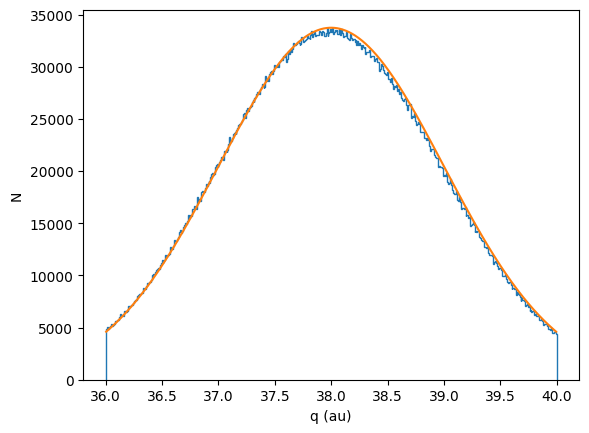

In [5]:
# confirm that the 'q' distribution looks like what we want.
hot = Hot(size=10000000)
# import scipy
from matplotlib import pyplot  as plt
n = plt.hist(hot.q, histtype='step', bins=500)
plt.xlabel('q (au)')
plt.ylabel('N')
# expected function, normalized to match the histogram bins from the model 
x =  numpy.linspace((n[1][0]+n[1][1])/2, (n[1][-1]+n[1][-2])/2, 1000) * units.au
n = (numpy.exp(-(x - hot.q_centre) ** 2 / (2 * hot.q_width ** 2))) * numpy.array(n[0]).max()
plt.plot(x, n)

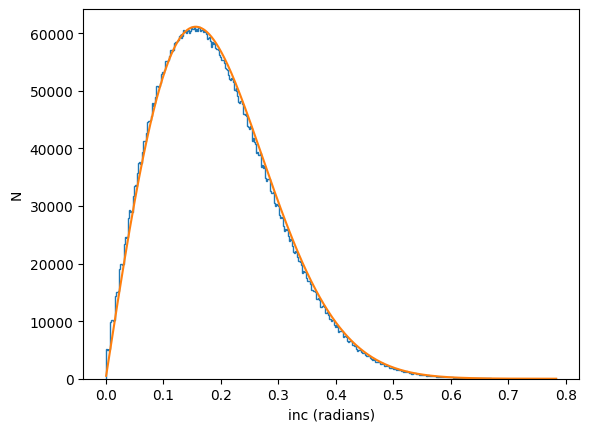

In [10]:
# confirm that the 'inc' distribution looks like what we want.
# import scipy
from matplotlib import pyplot  as plt
n = plt.hist(hot.inc, histtype='step', bins=500)
peak = numpy.array(n[0]).max()
plt.xlabel('inc (radians)')
plt.ylabel('N')
# expected function, normalized to match the histogram bins from the model 
x =  numpy.linspace((n[1][0]+n[1][1])/2, (n[1][-1]+n[1][-2])/2, 1000) * units.radian
n = numpy.sin(x)*(numpy.exp(-x ** 2 / (2 * (9/57.3*units.radian)** 2)))
n = peak*n/n.max()
plt.plot(x, n)

In [12]:
# to determine if an object was detectable we use an OSSSSim object, initializing it with the name of directory holding the 
# survey characterization of interest.
ssim = OSSSSim(characterization_directory=os.path.join(CHARACTERIZATION_DIR,'HST'), seed=123456789)

/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Encountered unknown field in file. File might have been saved with a different version of REBOUND.
  warnings.warn(message, RuntimeWarning)


In [15]:
os.listdir(CHARACTERIZATION_DIR)

['HST', 'CFEPS']

In [13]:
model = Hot(size=100000)

In [18]:
# let's create a model that is 50% twotinos and 50% 'Ring'
from numpy import random
import sys
n_detections = n_iterations = n_tracked = 0

def delete_if_file_exists(filename):
    import os
    if os.access(filename, os.F_OK):
        os.remove(filename)

model_filename = os.path.join(MODEL_OUTPUT_DIR,'example_model.txt')
detect_filename = os.path.join(MODEL_OUTPUT_DIR, 'example_detect.txt')

# Create some objects to store our model and our detections.
# First we delete any existing files with these names as all writes are appends.
for filename in [model_filename, detect_filename]:
    delete_if_file_exists(filename)
    
model_save_file=ModelOutputFile(filename=model_filename)
detect_save_file=DetectFile(filename=detect_filename)


total_iterations = 1

while n_detections < total_iterations:
    n_iterations += 1
    row = next(model)
    model_save_file.write_row(row)
    result = ssim.simulate(row, 
                           epoch=model.epoch, 
                           colors=model.colors, 
                           model_band=model.model_band,
                           debug=False)
    if result['flag'] > 0:
        n_detections += 1
    detect_save_file.write_row(result)

/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/kavelaarsj/venv/lib/python3.12/site-packages/rebound/simulation.py:153: RuntimeWarning: Encountered unknown field in file. File might have been saved with a different version of REBOUND.
  warnings.warn(message, RuntimeWarning)
/Users/kavelaarsj/venv/lib/python3.12/site-packages/astropy/table/table.py:3245: UserWarning: Units from inserted quantities will be ignored.
If you were hoping to fill a QTable row by row, also initialize the units before starting, for instance
QTable(names=['a', 'e', 'inc', 'node', 'peri', 'M', 'H', 'q', 'comp', 'j', 'k', 'x', 'y', 'z'], units=['AU', '', 'deg', 'deg', 'deg', 'deg', 'mag', 'AU', None, None, None, 'AU', 'AU', 'AU'])
  self.insert_row(len(self), vals, mask)


ValueError: _ossssimlib._ossssimlib.f90wrap_surveysub__detos1: failed to create array from the 4th argument `color` -- 0-th dimension must be fixed to 128 but got 59

In [ ]:
# some diagnostic plots
import matplotlib as mpl
from matplotlib import pyplot
# This installation has no fonts, if working on a local device you might set your font here.
mpl.rcParams['font.family'] = []
mpl.rcParams['font.serif'] = []
pyplot.plot(model_save_file.table['a'], model_save_file.table['e'], ',g', label='cold')
pyplot.ylabel('e')
pyplot.xlabel('a (au)')
pyplot.legend()

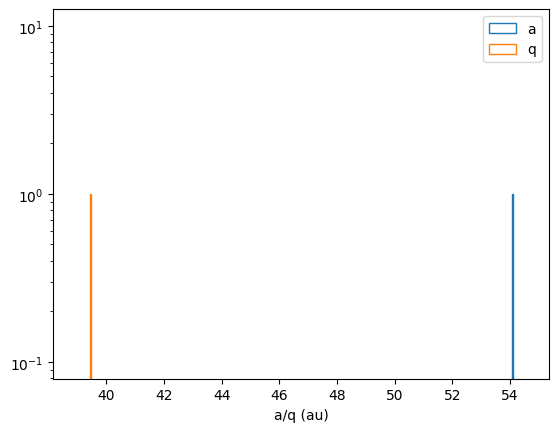

In [22]:
a = numpy.array(model_save_file.table['a'])
q = numpy.array(model_save_file.table['q'])
pyplot.hist(a, bins=30, histtype='step', label='a')
pyplot.hist(q, bins=30, histtype='step', label='q')
# pyplot.ylabel('q (au)')
pyplot.xlabel('a/q (au)')
pyplot.yscale('log')
pyplot.legend()

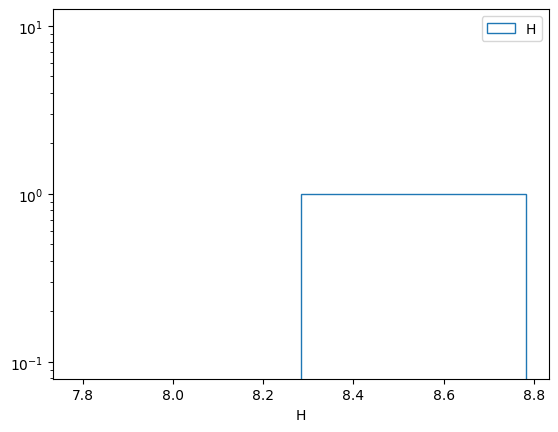

In [23]:
H = numpy.array(model_save_file.table['H'])
pyplot.hist(H, cumulative=True, bins=30, histtype='step', label='H')
# pyplot.ylabel('q (au)')
pyplot.xlabel('H')
pyplot.yscale('log')
pyplot.legend()

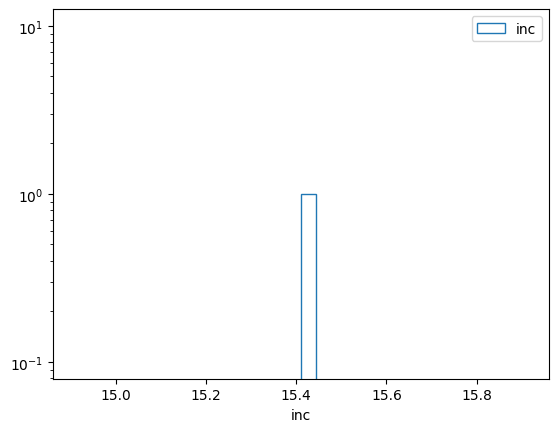

In [12]:
inc = numpy.array(model_save_file.table['inc'])
pyplot.hist(inc, cumulative=False, bins=30, histtype='step', label='inc')
# pyplot.ylabel('q (au)')
pyplot.xlabel('inc')
pyplot.yscale('log')
pyplot.legend()

/opt/SSim/python/ossssim/plotter.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  self.ax1.set_xticklabels(x_tick_labels, color='b', alpha=0.6)


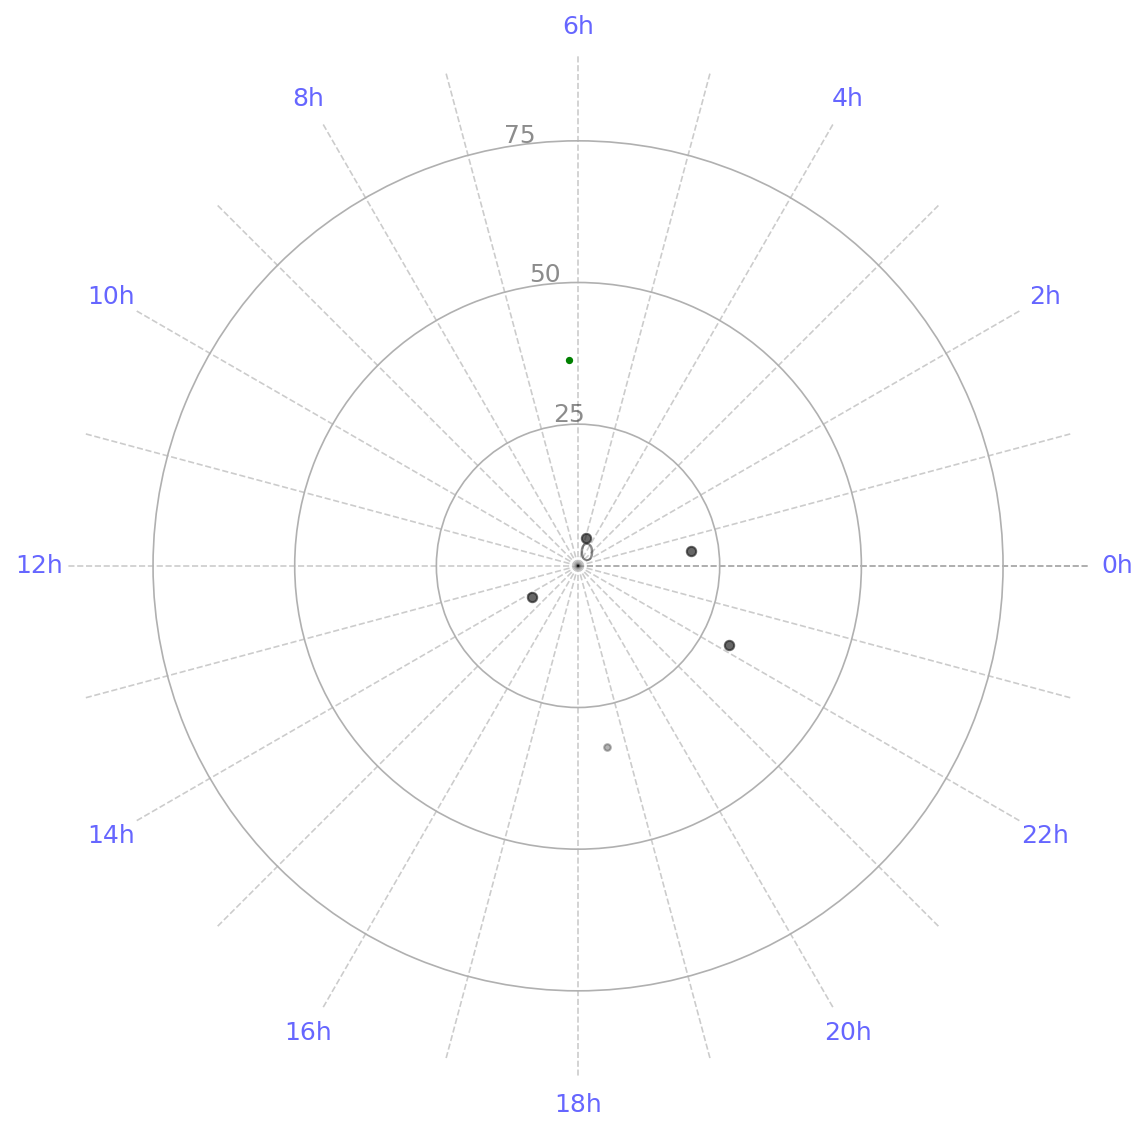

In [13]:
import matplotlib as mpl
from ossssim import plotter
# This installation has no fonts, if working on a local device you might set your font here.
mpl.rcParams['font.family'] = []
mpl.rcParams['font.serif'] = []

plot = plotter.RosePlot(epoch=model_save_file.epoch)
plot.add_model(model_save_file, ms=0.1, mc='k', alpha=0.2)
plot.add_model(detect_save_file, ms=5, mc='g')
plot.add_planets()
plot.show()
